import pandas as pd
import numpy as np

print("ready 🚀")

In [1]:
import pandas as pd
import numpy as np

print("ready 🚀")

ready 🚀


In [2]:
df = df.sort_values(['scheme', 'date'])

df['daily_return'] = df.groupby('scheme')['nav'].pct_change()

NameError: name 'df' is not defined

In [3]:
import pandas as pd


In [4]:
df = pd.read_csv("../data/raw/01_fund_master.csv")

In [5]:
df.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [6]:
df = df.sort_values(['scheme', 'date'])

df['daily_return'] = df.groupby('scheme')['nav'].pct_change()

KeyError: 'scheme'

In [7]:
import os
os.listdir("../data/raw/")


['01_fund_master.csv',
 '02_nav_history.csv',
 '03_aum_by_fund_house.csv',
 '04_monthly_sip_inflows.csv',
 '05_category_inflows.csv',
 '06_industry_folio_count.csv',
 '07_scheme_performance.csv',
 '08_investor_transactions.csv',
 '09_portfolio_holdings.csv',
 'live_nav_data.csv']

In [8]:
import pandas as pd

df = pd.read_csv("../data/raw/02_nav_history.csv")

df.head()


,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [9]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  str    
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.1 MB


In [10]:
date = str

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  str    
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.1 MB


In [12]:
df['date'] = pd.to_datetime(df['date'])

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[us]
 2   nav        46000 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 1.1 MB


In [16]:
df = df.sort_values(['amfi_code', 'date'])
df.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


In [15]:
df['daily_return'] = df.groupby('amfi_code')['nav'].pct_change()

In [17]:
df.head(10)

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639
5756,100016,2022-01-11,513.5542,0.005562
5757,100016,2022-01-12,512.3195,-0.002404
5758,100016,2022-01-13,510.2445,-0.004050
5759,100016,2022-01-14,514.3636,0.008073


In [18]:
import numpy as np


In [19]:
def cagr(start, end, years):
    return (end / start) ** (1/years) - 1

In [20]:
cagr_list = []

for fund, data in df.groupby('amfi_code'):
    data = data.sort_values('date')
    
    start_nav = data.iloc[0]['nav']
    end_nav = data.iloc[-1]['nav']
    
    years = (data['date'].max() - data['date'].min()).days / 365
    
    cagr_value = cagr(start_nav, end_nav, years)
    
    cagr_list.append([fund, cagr_value])

cagr_df = pd.DataFrame(cagr_list, columns=['amfi_code', 'CAGR'])
cagr_df.head()

,amfi_code,CAGR
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331


In [21]:
df['daily_return'] = df.groupby('amfi_code')['nav'].pct_change()

In [22]:
Rf = 0.065  # 6.5% annual risk-free rate

sharpe_list = []

for fund, data in df.groupby('amfi_code'):
    r = data['daily_return'].dropna()
    
    mean_return = r.mean()
    std_return = r.std()
    
    sharpe = ((mean_return - Rf/252) / std_return) * np.sqrt(252)
    
    sharpe_list.append([fund, sharpe])

sharpe_df = pd.DataFrame(sharpe_list, columns=['amfi_code', 'Sharpe'])
sharpe_df.head()

,amfi_code,Sharpe
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [23]:
sortino_list = []

for fund, data in df.groupby('amfi_code'):
    r = data['daily_return'].dropna()
    
    mean_return = r.mean()
    
    downside = r[r < 0]
    downside_std = downside.std()
    
    if downside_std == 0 or np.isnan(downside_std):
        sortino = np.nan
    else:
        sortino = ((mean_return - 0) / downside_std) * np.sqrt(252)
    
    sortino_list.append([fund, sortino])

sortino_df = pd.DataFrame(sortino_list, columns=['amfi_code', 'Sortino'])
sortino_df.head()

,amfi_code,Sortino
0,100016,0.427276
1,100025,1.822432
2,100033,2.403193
3,101206,2.581215
4,101207,0.705169


In [24]:
import os
os.listdir("../data/raw/")

['01_fund_master.csv',
 '02_nav_history.csv',
 '03_aum_by_fund_house.csv',
 '04_monthly_sip_inflows.csv',
 '05_category_inflows.csv',
 '06_industry_folio_count.csv',
 '07_scheme_performance.csv',
 '08_investor_transactions.csv',
 '09_portfolio_holdings.csv',
 'live_nav_data.csv']

In [25]:
bench = pd.read_csv("../data/raw/07_scheme_performance.csv")
bench.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [26]:
alpha_beta_df = bench[['amfi_code', 'alpha', 'beta']]
alpha_beta_df.head()

,amfi_code,alpha,beta
0,119551,0.87,0.89
1,119552,1.78,0.87
2,119598,1.23,0.89
3,119599,1.13,1.04
4,119120,1.60,0.22


In [27]:
alpha_beta_df.to_csv("alpha_beta.csv", index=False)

In [28]:
drawdown_list = []

for fund, data in df.groupby('amfi_code'):
    data = data.sort_values('date')
    
    running_max = data['nav'].cummax()
    drawdown = data['nav'] / running_max - 1
    
    max_dd = drawdown.min()
    
    drawdown_list.append([fund, max_dd])

dd_df = pd.DataFrame(drawdown_list, columns=['amfi_code', 'max_drawdown'])
dd_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [29]:
scorecard = bench[['amfi_code', 'return_3yr_pct', 'sharpe_ratio', 'alpha', 'expense_ratio_pct', 'max_drawdown_pct']].copy()


In [30]:
scorecard['return_rank'] = scorecard['return_3yr_pct'].rank(ascending=False)
scorecard['sharpe_rank'] = scorecard['sharpe_ratio'].rank(ascending=False)
scorecard['alpha_rank'] = scorecard['alpha'].rank(ascending=False)
scorecard['expense_rank'] = scorecard['expense_ratio_pct'].rank(ascending=True)
scorecard['dd_rank'] = scorecard['max_drawdown_pct'].rank(ascending=False)

In [31]:
scorecard['score'] = (
    0.30 * scorecard['return_rank'] +
    0.25 * scorecard['sharpe_rank'] +
    0.20 * scorecard['alpha_rank'] +
    0.15 * scorecard['expense_rank'] +
    0.10 * scorecard['dd_rank']
)

scorecard = scorecard.sort_values('score', ascending=True)
scorecard.head()

,amfi_code,return_3yr_pct,sharpe_ratio,alpha,expense_ratio_pct,max_drawdown_pct,return_rank,sharpe_rank,alpha_rank,expense_rank,dd_rank,score
22,120843,15.65,0.98,1.85,1.45,-19.50,11.0,12.0,3.5,22.0,20.0,12.30
2,119598,23.39,0.94,1.23,1.43,-13.35,1.0,18.0,20.0,21.0,8.0,12.75
14,120507,7.68,7.68,1.85,0.74,-2.62,35.0,1.0,3.5,7.0,3.0,12.80
9,100025,7.37,1.84,1.98,0.56,-6.01,36.0,4.0,1.0,2.0,6.0,12.90
21,120842,18.23,0.96,1.91,1.56,-21.92,7.0,15.0,2.0,33.0,25.0,13.70


In [32]:
scorecard.to_csv("fund_scorecard.csv", index=False)

In [33]:
top5 = scorecard.head(5)
top5

,amfi_code,return_3yr_pct,sharpe_ratio,alpha,expense_ratio_pct,max_drawdown_pct,return_rank,sharpe_rank,alpha_rank,expense_rank,dd_rank,score
22,120843,15.65,0.98,1.85,1.45,-19.50,11.0,12.0,3.5,22.0,20.0,12.30
2,119598,23.39,0.94,1.23,1.43,-13.35,1.0,18.0,20.0,21.0,8.0,12.75
14,120507,7.68,7.68,1.85,0.74,-2.62,35.0,1.0,3.5,7.0,3.0,12.80
9,100025,7.37,1.84,1.98,0.56,-6.01,36.0,4.0,1.0,2.0,6.0,12.90
21,120842,18.23,0.96,1.91,1.56,-21.92,7.0,15.0,2.0,33.0,25.0,13.70


In [34]:
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


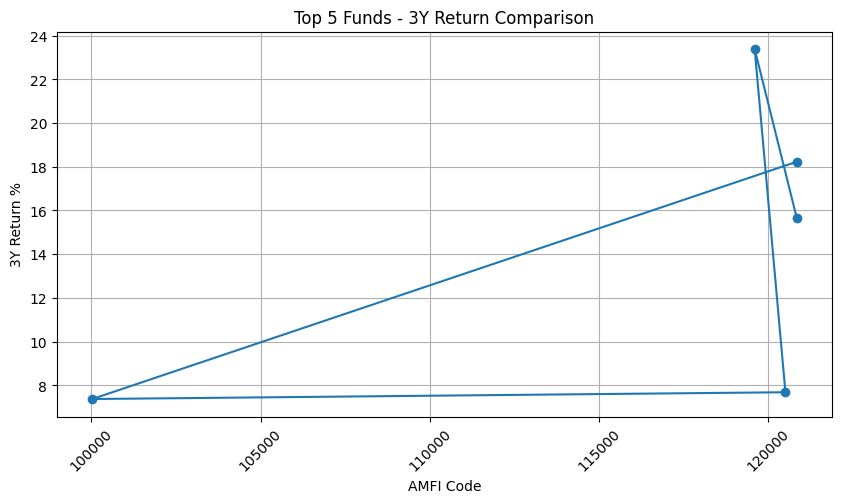

In [35]:
plt.figure(figsize=(10,5))

plt.plot(top5['amfi_code'], top5['return_3yr_pct'], marker='o')

plt.title("Top 5 Funds - 3Y Return Comparison")
plt.xlabel("AMFI Code")
plt.ylabel("3Y Return %")

plt.xticks(rotation=45)
plt.grid()

plt.show()

In [36]:
plt.savefig("benchmark_comparison.png")

<Figure size 640x480 with 0 Axes>

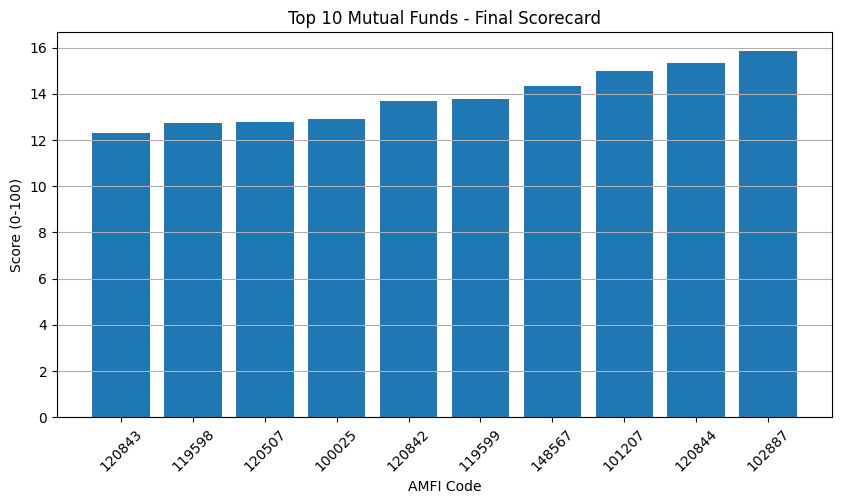

In [37]:
import matplotlib.pyplot as plt

top10 = scorecard.head(10)

plt.figure(figsize=(10,5))
plt.bar(top10['amfi_code'].astype(str), top10['score'])

plt.title("Top 10 Mutual Funds - Final Scorecard")
plt.xlabel("AMFI Code")
plt.ylabel("Score (0-100)")
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.show()

In [38]:
plt.savefig("benchmark_comparison.png")

<Figure size 640x480 with 0 Axes>

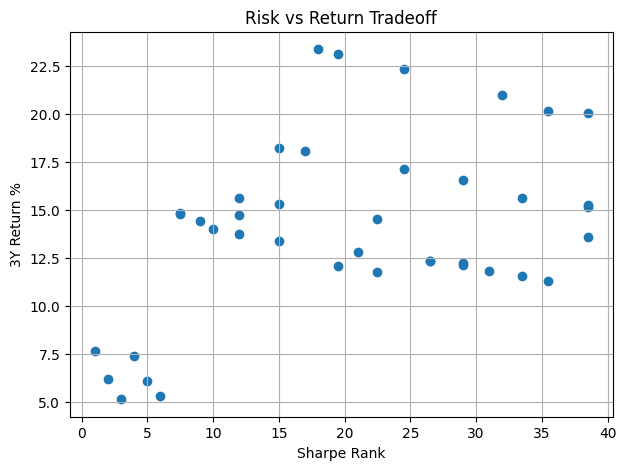

In [39]:
plt.figure(figsize=(7,5))

plt.scatter(scorecard['sharpe_rank'], scorecard['return_3yr_pct'])

plt.title("Risk vs Return Tradeoff")
plt.xlabel("Sharpe Rank")
plt.ylabel("3Y Return %")

plt.grid()
plt.show()

In [40]:
top5 = scorecard.nsmallest(5, 'score')  # best score = lowest rank value (as per your setup)
top5


,amfi_code,return_3yr_pct,sharpe_ratio,alpha,expense_ratio_pct,max_drawdown_pct,return_rank,sharpe_rank,alpha_rank,expense_rank,dd_rank,score
22,120843,15.65,0.98,1.85,1.45,-19.50,11.0,12.0,3.5,22.0,20.0,12.30
2,119598,23.39,0.94,1.23,1.43,-13.35,1.0,18.0,20.0,21.0,8.0,12.75
14,120507,7.68,7.68,1.85,0.74,-2.62,35.0,1.0,3.5,7.0,3.0,12.80
9,100025,7.37,1.84,1.98,0.56,-6.01,36.0,4.0,1.0,2.0,6.0,12.90
21,120842,18.23,0.96,1.91,1.56,-21.92,7.0,15.0,2.0,33.0,25.0,13.70


In [41]:
bench.columns

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')

In [42]:
bench = bench[['amfi_code','return_3yr_pct']]  # if needed adjust later

In [43]:
compare = top5[['amfi_code','return_3yr_pct','sharpe_ratio']].copy()
compare

,amfi_code,return_3yr_pct,sharpe_ratio
22,120843,15.65,0.98
2,119598,23.39,0.94
14,120507,7.68,7.68
9,100025,7.37,1.84
21,120842,18.23,0.96


In [44]:
import numpy as np

tracking_error = df.groupby('amfi_code')['daily_return'].std().mean() * np.sqrt(252)

tracking_error

np.float64(0.14944360780211852)